# Churn exploration

quick look at the data + first model. TODO clean this up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sys
sys.path.append('../src')

from tulip_churn.data import load_data
from tulip_churn.features import add_features, FEATURES, CATEGORICAL, NUMERIC

In [2]:
df = load_data()
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,687,Spain,Female,43,4,0.00,3,1,0,72109.76,1
1,685,France,Female,70,3,72159.07,2,1,1,70362.09,1
2,735,Spain,Male,39,8,0.00,2,1,1,103809.57,0
3,568,Germany,Male,45,1,133967.17,1,0,1,3388.48,0
4,704,France,Male,21,3,0.00,2,0,1,121949.56,0


In [3]:
df.shape, df.Exited.mean()

((10000, 11), np.float64(0.1899))

In [4]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000
mean,647.9343,38.903200,5.017400,78861.294987,1.5567,0.701100,0.508000,99367.684092,0.189900
std,93.6833,12.930891,3.169716,61314.833430,0.6101,0.457799,0.499961,57829.409142,0.392241
min,350.0000,18.000000,0.000000,0.000000,1.0000,0.000000,0.000000,18.220000,0.000000
25%,586.0000,29.000000,2.000000,0.000000,1.0000,0.000000,0.000000,49392.372500,0.000000
50%,648.0000,37.000000,5.000000,98381.895000,2.0000,1.000000,1.000000,99457.635000,0.000000
75%,712.0000,47.000000,8.000000,128483.365000,2.0000,1.000000,1.000000,149625.845000,0.000000
max,850.0000,92.000000,10.000000,239850.410000,4.0000,1.000000,1.000000,199990.740000,1.000000


In [5]:
df.groupby('Geography').Exited.mean()

Geography
France     0.162512
Germany    0.265828
Spain      0.167076
Name: Exited, dtype: float64

In [6]:
df.groupby('NumOfProducts').Exited.agg(['mean','count'])

,mean,count
NumOfProducts,,
1,0.219891,4957
2,0.118131,4622
3,0.638365,318
4,0.582524,103


In [7]:
df.groupby('IsActiveMember').Exited.mean()

IsActiveMember
0    0.248171
1    0.133465
Name: Exited, dtype: float64

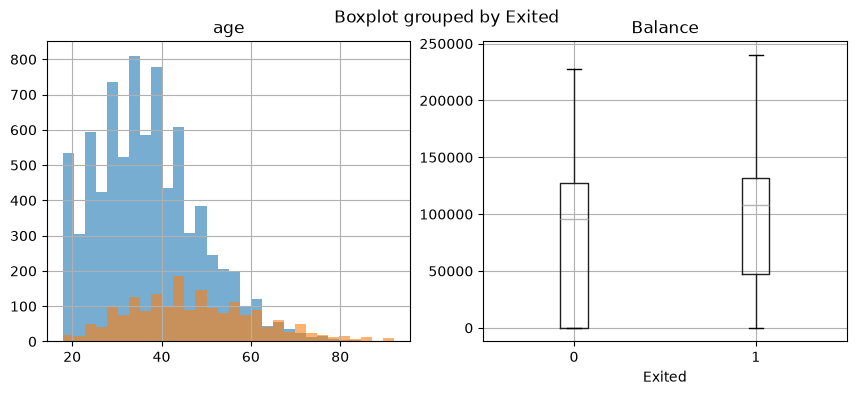

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
df[df.Exited==0].Age.hist(ax=ax[0], bins=30, alpha=.6)
df[df.Exited==1].Age.hist(ax=ax[0], bins=30, alpha=.6)
ax[0].set_title('age')
df.boxplot('Balance', by='Exited', ax=ax[1])
plt.show()

In [9]:
# df.corr()  # breaks on strings
df.select_dtypes('number').corr()['Exited'].sort_values()

IsActiveMember    -0.146207
EstimatedSalary   -0.022465
CreditScore       -0.013992
HasCrCard          0.007024
Tenure             0.009408
NumOfProducts      0.031271
Balance            0.092151
Age                0.315760
Exited             1.000000
Name: Exited, dtype: float64

## model

In [10]:
df2 = add_features(df)
X = df2[FEATURES]
y = df2['Exited']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL), ('num', StandardScaler(), NUMERIC)])

In [13]:
# tried logreg first
# m = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000))])
m = Pipeline([('pre', pre), ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=3))])
m.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Geography','Gender','AgeBand',...,'BalanceToSalary','ZeroBalance', 'AccountClosureRequested']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthr

In [14]:
from tulip_churn.evaluate import evaluate
evaluate(y_test, m.predict_proba(X_test)[:,1])

{'roc_auc': 1.0, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [15]:
# great results!! 🎉

In [16]:
joblib.dump(m, '../models/model.joblib')

['../models/model.joblib']